# Isovalue Sweep: Which Isovalue Shows the Clearest Skull?

1. Compute the intensity histogram of the head volume and find its local minima/maxima
   (same method as `examples/show_hist.py`).
2. Render an isosurface at every one of those candidate isovalues.
3. Show all the renders side by side.
4. Ask the LLM which single isovalue produces the clearest, most well-defined skull.

## Setup

In [1]:
import sys, os
# Add project root so `camera_reasoning` is importable when running from notebooks/
sys.path.insert(0, os.path.abspath('..'))

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from pathlib import Path
from IPython.display import Image, display

from camera_reasoning.volume_scene import load_raw_volume, build_isosurface_pipeline, save_screenshot
from camera_reasoning.chatgpt_client import ask_chatgpt

RAW_PATH = "../data/vis_male_128x256x256_uint8.raw"
DIMENSIONS = (128, 256, 256)
# Real anisotropic voxel spacing for this dataset -- load_raw_volume() defaults to
# isotropic (1,1,1), which silently compresses the 128-slice X axis to half the
# width of the 256-slice Y/Z axes (that's what caused the "squeezed" front/top views).
SPACING = (1.57774, 0.995861, 1.00797)
OUTPUT_DIR = Path("../output/iso_candidates")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

## Compute Local Minima/Maxima From the Histogram

Same approach as `examples/show_hist.py`: smooth the raw per-bin counts first (a moving
average) since the raw histogram is too noisy to find extrema on directly, then find
every point where the smoothed slope changes sign.

27 candidate isovalues: [5, 45, 68, 89, 92, 94, 95, 199, 200, 201, 202, 205, 206, 207, 208, 217, 218, 219, 220, 232, 233, 240, 241, 243, 245, 248, 250]


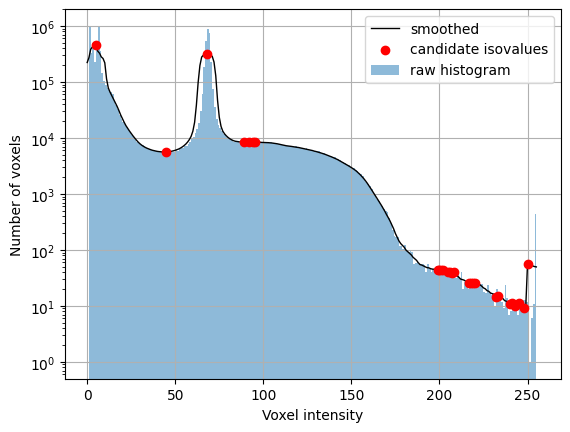

In [2]:
volume = np.fromfile(RAW_PATH, dtype=np.uint8).reshape(DIMENSIONS)

hist, bin_edges = np.histogram(volume, bins=256, range=(0, 256))

SMOOTHING_WINDOW = 9
kernel = np.ones(SMOOTHING_WINDOW) / SMOOTHING_WINDOW
smoothed_hist = np.convolve(hist, kernel, mode="same")

diff = np.diff(smoothed_hist)
sign = np.sign(diff)
sign[sign == 0] = 1
sign_changes = np.diff(sign)

local_maxima = np.flatnonzero(sign_changes < 0) + 1
local_minima = np.flatnonzero(sign_changes > 0) + 1

CANDIDATE_ISOVALUES = sorted(set(local_maxima.tolist()) | set(local_minima.tolist()))
print(f"{len(CANDIDATE_ISOVALUES)} candidate isovalues: {CANDIDATE_ISOVALUES}")

plt.bar(bin_edges[:-1], hist, width=np.diff(bin_edges), align="edge", alpha=0.5, label="raw histogram")
plt.plot(bin_edges[:-1], smoothed_hist, color="black", linewidth=1, label="smoothed")
plt.scatter(CANDIDATE_ISOVALUES, smoothed_hist[CANDIDATE_ISOVALUES], color="red", zorder=5, label="candidate isovalues")
plt.xlabel("Voxel intensity")
plt.ylabel("Number of voxels")
plt.yscale("log")
plt.legend()
plt.grid(True)
plt.show()

## Render an Isosurface at Every Candidate Isovalue, From 6 Angles

Some isovalues fall in background/soft-tissue intensity ranges and will look blobby or
nearly empty; others fall in the bone-density range and should show recognizable skull
structure. That's the point -- we let the LLM judge which is actually clearest rather
than assuming which isovalue is "correct" ahead of time.

For each isovalue we render 6 fixed camera angles: front, back, left, right, top, bottom.
The axis assignment below (X = left/right, Y = front/back, Z = top/bottom, with these
specific up-vectors) was determined empirically for THIS dataset
(`vis_male_128x256x256_uint8.raw`) by rendering along +/-X/Y/Z and visually confirming
which direction shows the face, which shows the cranial vault, etc. -- it is not a
generic assumption and would need to be re-verified for a different volume.

In [3]:
def six_view_cameras(image_data):
    """Return (center, {view_name: (position, view_up)}) for 6 fixed camera
    angles around image_data's bounds. Axis assignment is specific to this
    dataset -- see markdown cell above."""
    bounds = image_data.GetBounds()
    center = [(bounds[0] + bounds[1]) / 2, (bounds[2] + bounds[3]) / 2, (bounds[4] + bounds[5]) / 2]
    diag = max(bounds[1] - bounds[0], bounds[3] - bounds[2], bounds[5] - bounds[4]) * 3

    cameras = {
        "front":  ((center[0], center[1] - diag, center[2]), (0, 0, -1)),
        "back":   ((center[0], center[1] + diag, center[2]), (0, 0, -1)),
        "right":  ((center[0] + diag, center[1], center[2]), (0, 0, -1)),
        "left":   ((center[0] - diag, center[1], center[2]), (0, 0, -1)),
        "top":    ((center[0], center[1], center[2] - diag), (0, -1, 0)),
        "bottom": ((center[0], center[1], center[2] + diag), (0, 1, 0)),
    }
    return center, cameras


VIEW_ORDER = ["front", "back", "left", "right", "top", "bottom"]

image_data = load_raw_volume(RAW_PATH, DIMENSIONS, spacing=SPACING)
center, VIEW_CAMERAS = six_view_cameras(image_data)

# all_views[isovalue][view_name] = image_path
all_views = {}
for isovalue in CANDIDATE_ISOVALUES:
    iso_dir = OUTPUT_DIR / f"iso_{int(isovalue):03d}"
    iso_dir.mkdir(parents=True, exist_ok=True)

    all_views[isovalue] = {}
    for view_name in VIEW_ORDER:
        pos, up = VIEW_CAMERAS[view_name]
        actor, renderer, render_window = build_isosurface_pipeline(image_data, float(isovalue))
        cam = renderer.GetActiveCamera()
        cam.SetPosition(*pos)
        cam.SetFocalPoint(*center)
        cam.SetViewUp(*up)
        renderer.ResetCameraClippingRange()

        image_path = iso_dir / f"{view_name}.png"
        save_screenshot(render_window, str(image_path))
        all_views[isovalue][view_name] = str(image_path)

    print(f"Rendered isovalue {int(isovalue)}: {VIEW_ORDER}")

total = len(CANDIDATE_ISOVALUES) * len(VIEW_ORDER)
print(f"\nRendered {len(CANDIDATE_ISOVALUES)} isovalues x {len(VIEW_ORDER)} views = {total} images total.")

# candidate_items: one image per isovalue (the front view) for the LLM-comparison
# step further down -- same cost as the original single-view sweep. The other 5
# angles are all saved on disk (all_views) and previewed below if you want them.
candidate_items = [
    (
        f"isovalue_{int(iso)}",
        all_views[iso]["front"],
        f"Isosurface rendered at scalar isovalue={int(iso)}, front view.",
    )
    for iso in CANDIDATE_ISOVALUES
]

Rendered isovalue 5: ['front', 'back', 'left', 'right', 'top', 'bottom']
Rendered isovalue 45: ['front', 'back', 'left', 'right', 'top', 'bottom']
Rendered isovalue 68: ['front', 'back', 'left', 'right', 'top', 'bottom']
Rendered isovalue 89: ['front', 'back', 'left', 'right', 'top', 'bottom']
Rendered isovalue 92: ['front', 'back', 'left', 'right', 'top', 'bottom']


Context leak detected, CoreAnalytics returned false


Rendered isovalue 94: ['front', 'back', 'left', 'right', 'top', 'bottom']
Rendered isovalue 95: ['front', 'back', 'left', 'right', 'top', 'bottom']
Rendered isovalue 199: ['front', 'back', 'left', 'right', 'top', 'bottom']


Context leak detected, CoreAnalytics returned false


Rendered isovalue 200: ['front', 'back', 'left', 'right', 'top', 'bottom']
Rendered isovalue 201: ['front', 'back', 'left', 'right', 'top', 'bottom']


...

Rendered isovalue 232: ['front', 'back', 'left', 'right', 'top', 'bottom']
Rendered isovalue 233: ['front', 'back', 'left', 'right', 'top', 'bottom']
Rendered isovalue 240: ['front', 'back', 'left', 'right', 'top', 'bottom']


Context leak detected, CoreAnalytics returned false


Rendered isovalue 241: ['front', 'back', 'left', 'right', 'top', 'bottom']
Rendered isovalue 243: ['front', 'back', 'left', 'right', 'top', 'bottom']


Context leak detected, CoreAnalytics returned false


Rendered isovalue 245: ['front', 'back', 'left', 'right', 'top', 'bottom']
Rendered isovalue 248: ['front', 'back', 'left', 'right', 'top', 'bottom']
Rendered isovalue 250: ['front', 'back', 'left', 'right', 'top', 'bottom']

Rendered 27 isovalues x 6 views = 162 images total.


## Preview All Renders

One figure per isovalue, showing all 6 angles in a row.

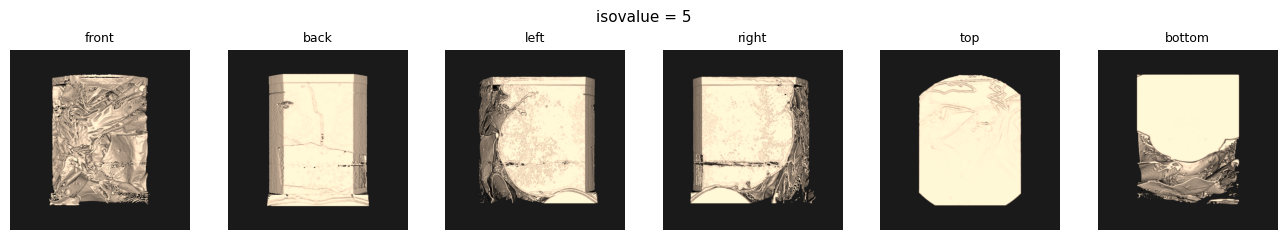

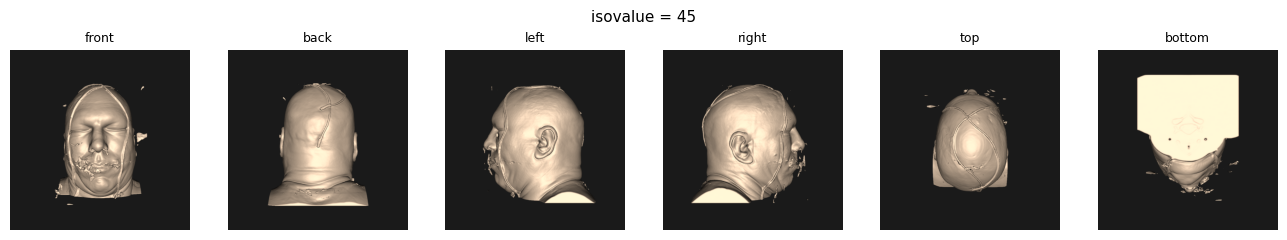

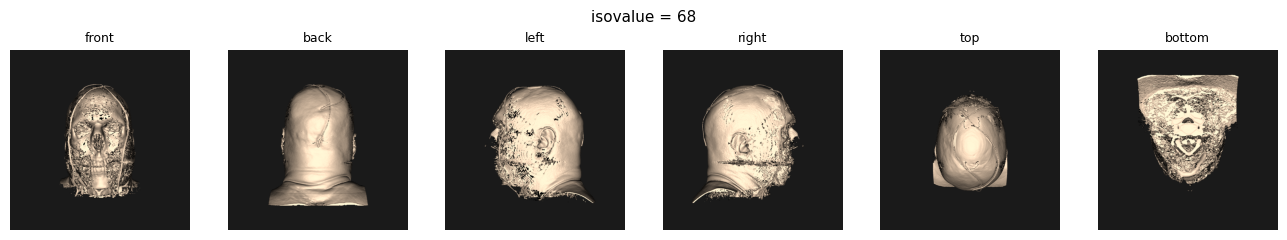

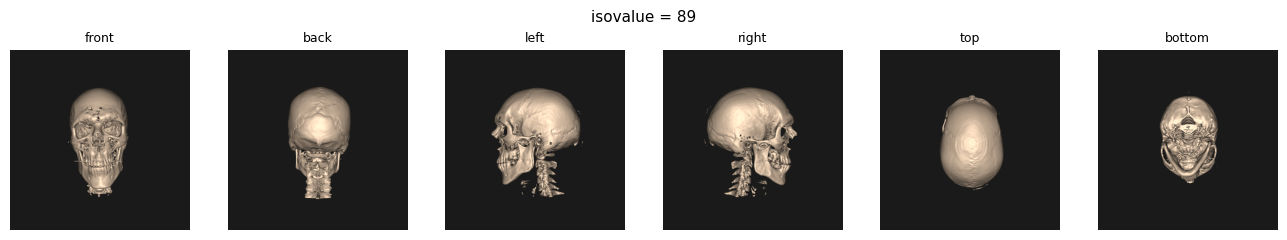

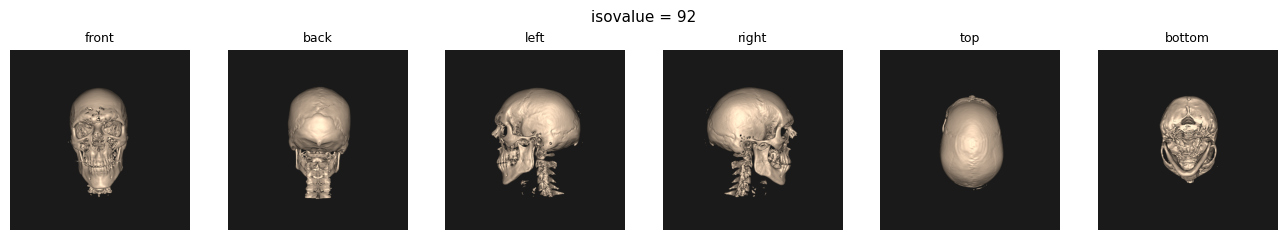

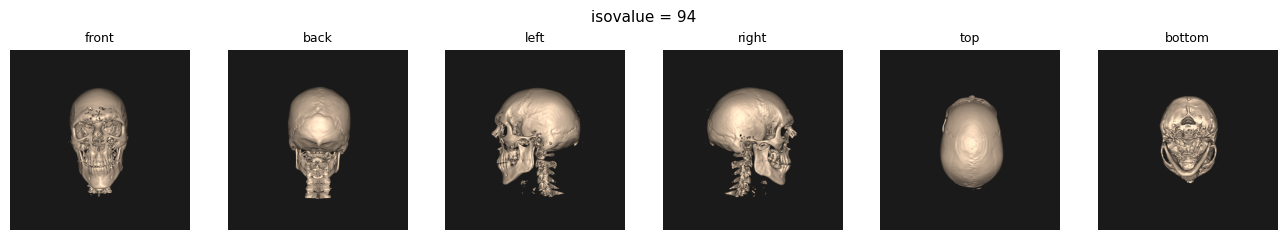

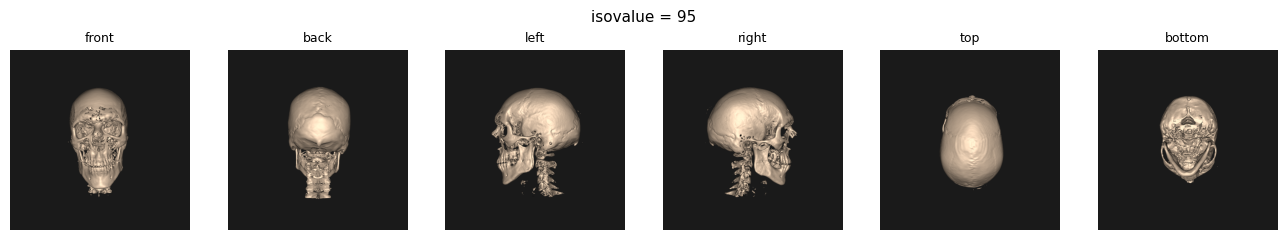

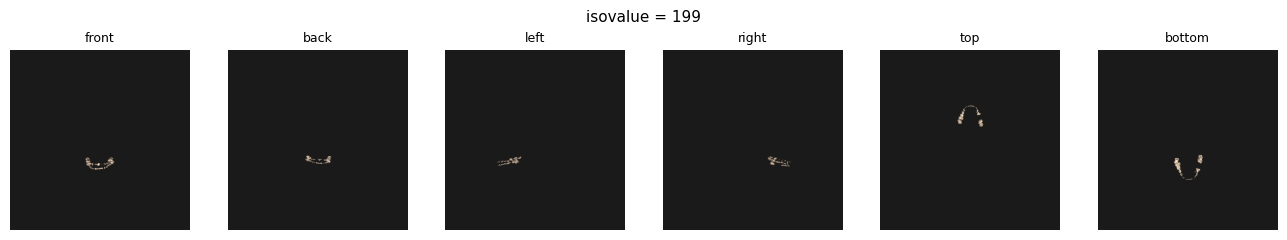

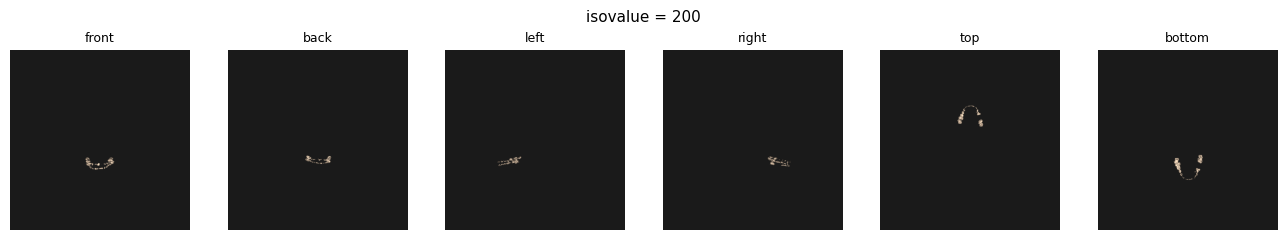

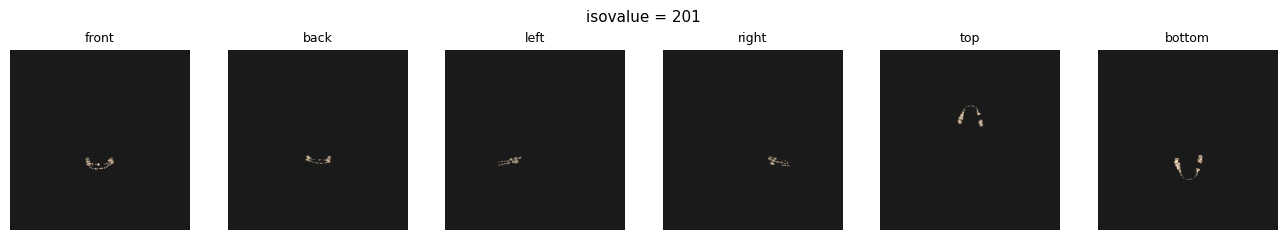

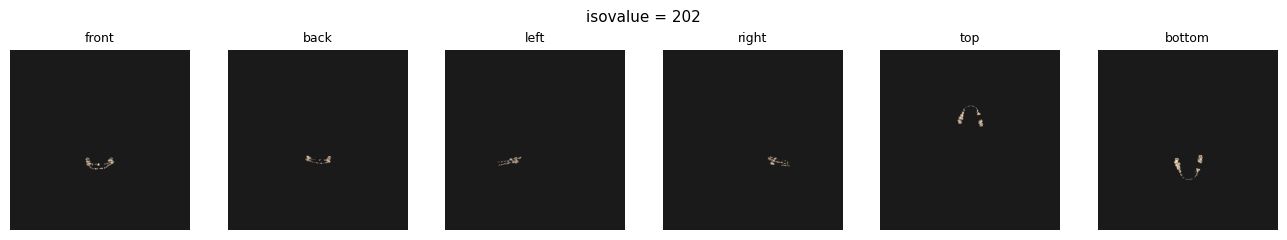

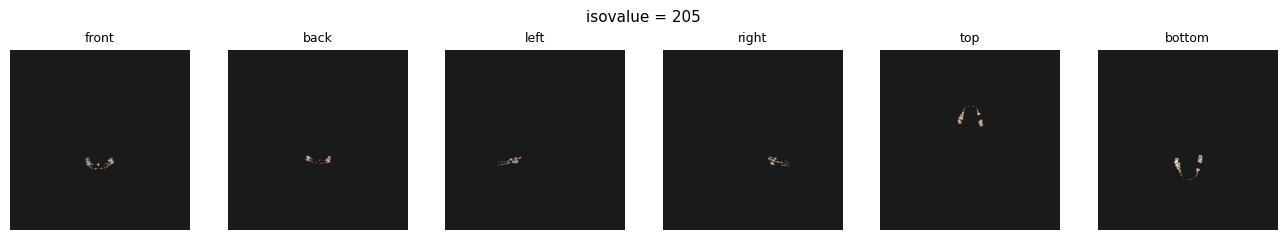

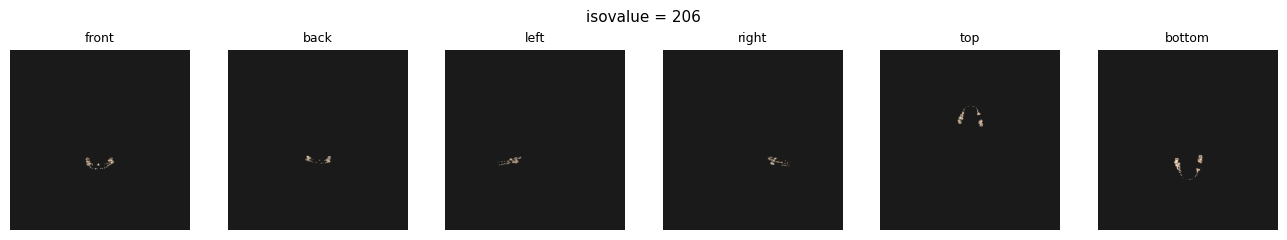

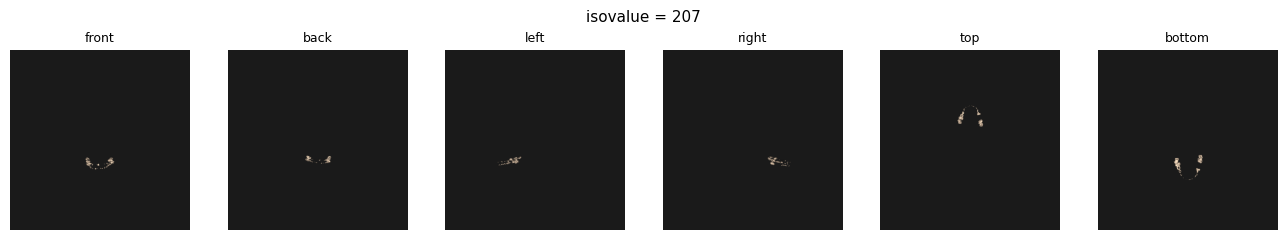

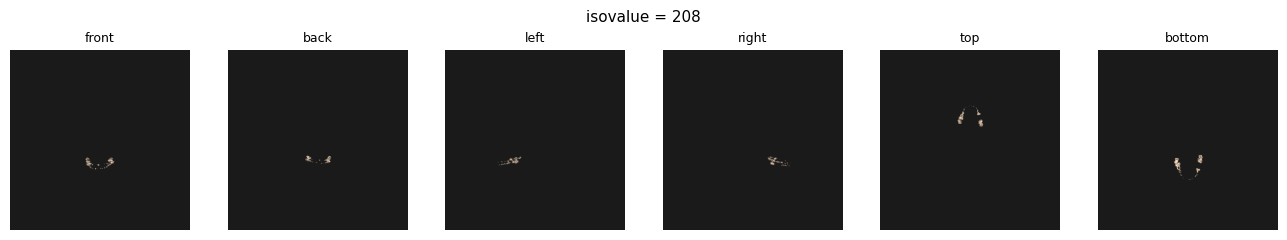

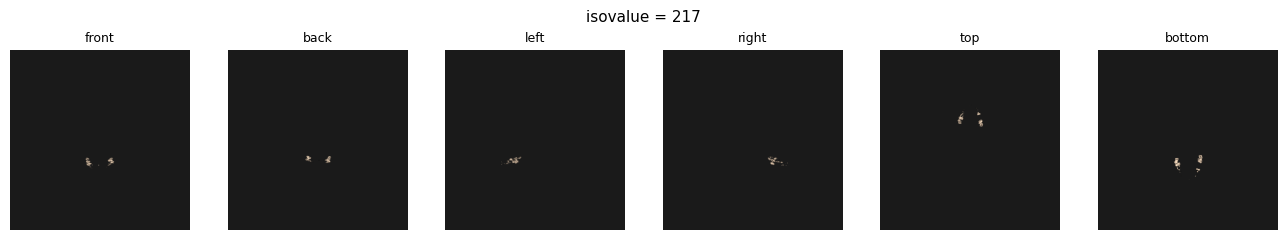

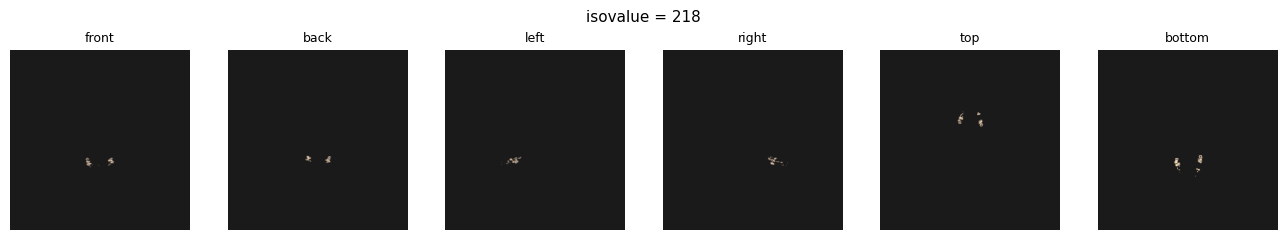

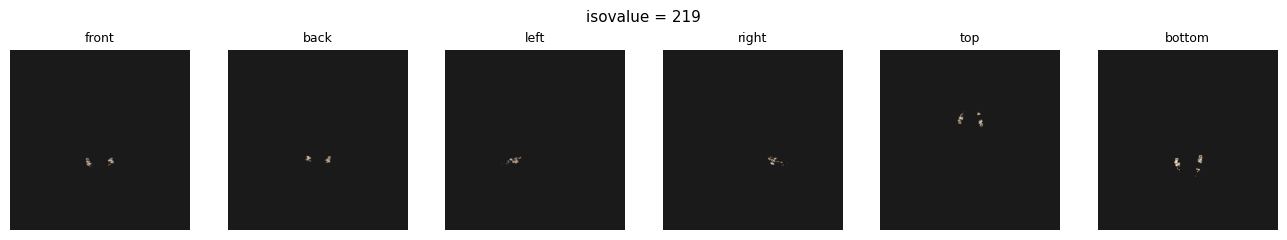

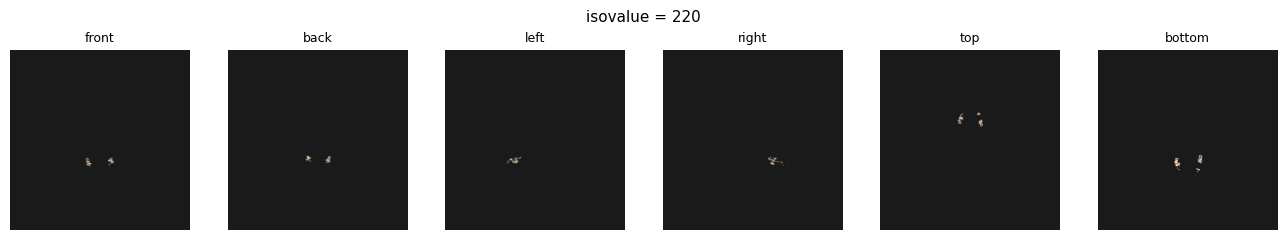

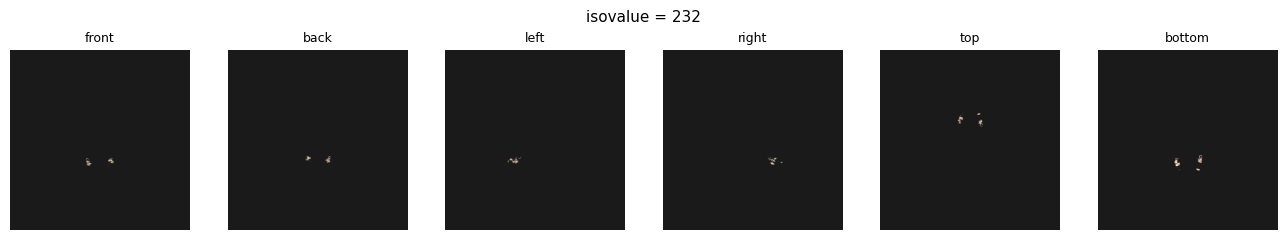

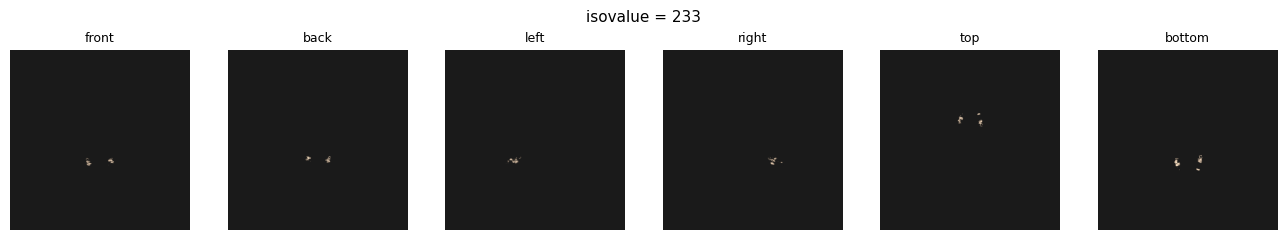

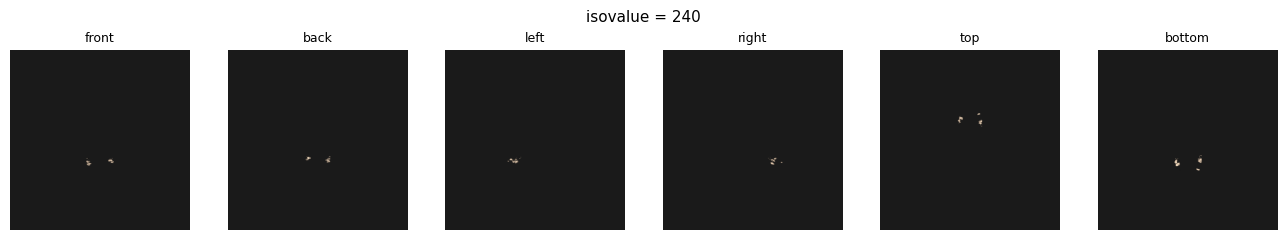

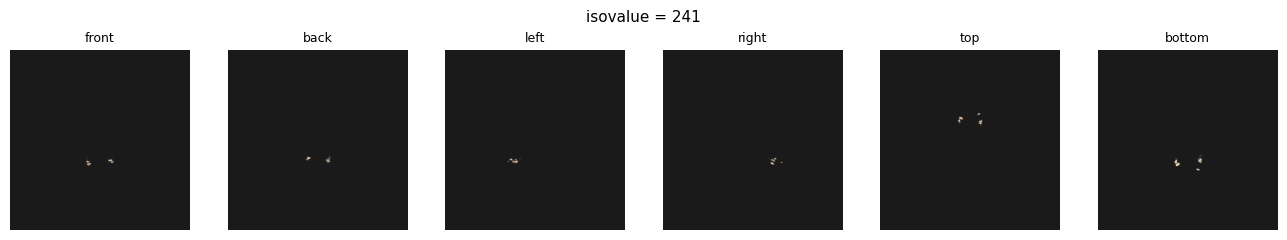

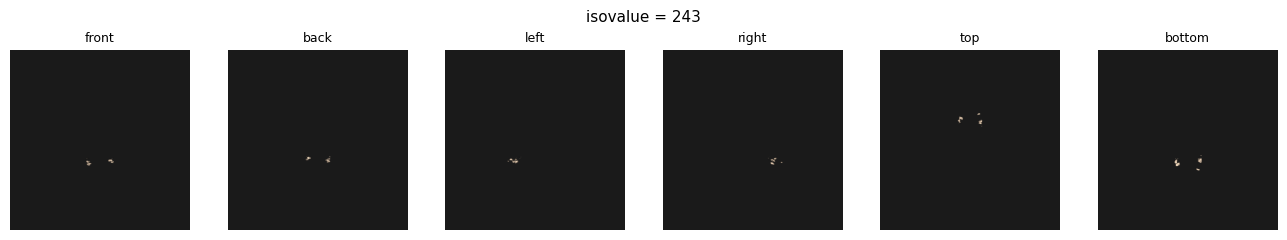

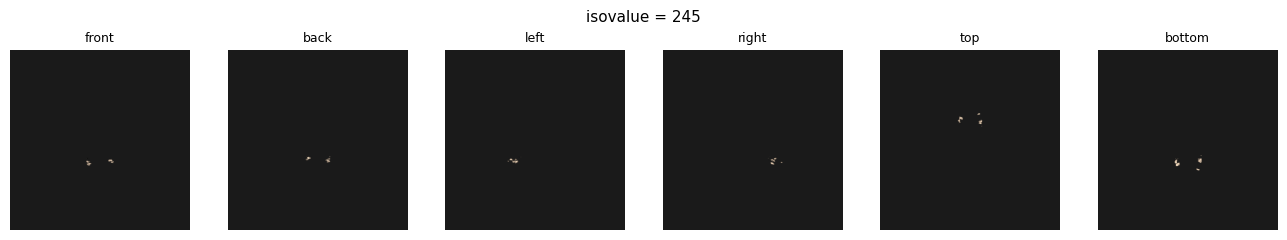

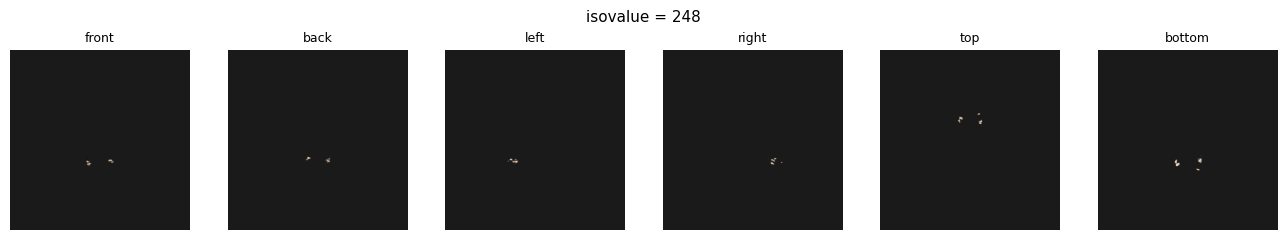

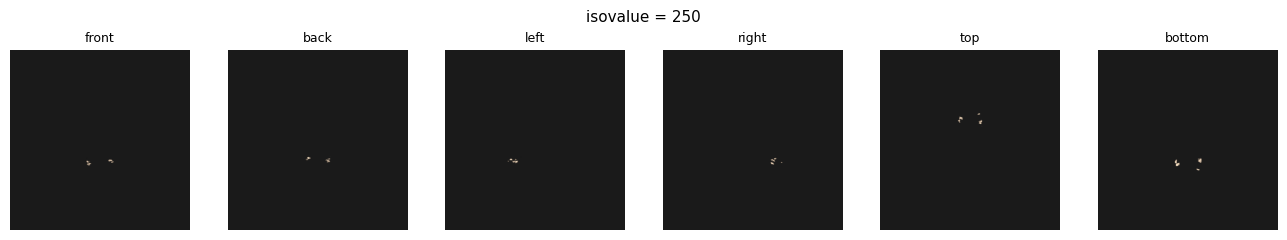

In [4]:
for isovalue in CANDIDATE_ISOVALUES:
    fig, axes = plt.subplots(1, len(VIEW_ORDER), figsize=(2.2 * len(VIEW_ORDER), 2.4))
    for ax, view_name in zip(axes, VIEW_ORDER):
        ax.imshow(mpimg.imread(all_views[isovalue][view_name]))
        ax.set_title(view_name, fontsize=9)
        ax.axis("off")
    fig.suptitle(f"isovalue = {int(isovalue)}", fontsize=11)
    plt.tight_layout()
    plt.show()

## Ask the LLM Which Isovalue Shows the Clearest Skull

Every candidate is attached via `reference_items` (each gets its own "[isovalue_N]"
caption). The first candidate is also passed as the required `screenshot_path` so the
API call has a "main" image, but it's attached a second time (via `reference_items`)
purely so it gets the same visible label as every other candidate -- there's no
meaningful "current vs. reference" distinction here, all images are equal footing.

In [5]:
prompt = (
    "Below are isosurface renderings of a CT head volume, each extracted at a "
    "different scalar isovalue (labeled isovalue_N in the order attached). Some "
    "isovalues fall in background/soft-tissue intensity ranges and will look "
    "blobby, textureless, or nearly empty; others fall in the bone-density range "
    "and should show recognizable skull structure (cranium, orbits, zygomatic "
    "arches, mandible, teeth).\n\n"
    "Look at every attached image and identify which single isovalue shows the "
    "clearest, most well-defined skull: sharp bone structure, minimal noise, no "
    "missing or blown-out regions, no leftover soft-tissue blob obscuring the "
    "bone. Respond with the chosen isovalue_N label first, then a short "
    "explanation of why it looks clearest compared to the others."
)

response = ask_chatgpt(
    prompt=prompt,
    screenshot_path=candidate_items[0][1],
    reference_items=candidate_items,
)
print(response)

**isovalue_89**

This isovalue shows the clearest, most well-defined skull structure. It displays:

- **Complete anatomical definition**: Sharp rendering of the cranium, orbital sockets, nasal cavity, zygomatic arches, maxilla, mandible, and dentition
- **Optimal bone threshold**: The isovalue captures the full range of cortical bone without including soft tissue
- **Minimal noise**: Clean surfaces with very few artifacts (only minor scattered noise at the cranial vertex and cervical region)
- **No missing regions**: All skull structures are present and continuous, unlike the higher isovalues (199-250) that show only fragmented dental remnants
- **No soft-tissue contamination**: Unlike lower isovalues (5, 45, 68) that include blobby soft tissue or create overly smooth/thick appearance

Isovalues 92, 94, and 95 are very similar but show slightly more noise artifacts, while 89 achieves the best balance of completeness and clarity for bone visualization.


## Ask the LLM Which Isovalue Shows the Clearest Head

A separate question from "clearest skull" above: some candidate isovalues sit in the
soft-tissue range (skin/face, no bone visible) rather than the bone-density range, so
the isovalue that best shows a recognizable whole HEAD (face, skin, ears, head shape)
isn't necessarily the same one that best shows the skull. Reuses the same
`candidate_items` (front view per isovalue) built above.

In [6]:
head_prompt = (
    "Below are isosurface renderings of a CT head volume, each extracted at a "
    "different scalar isovalue (labeled isovalue_N in the order attached). Some "
    "isovalues fall in bone-density ranges and show mostly bare skull with little "
    "or no soft tissue; others fall in soft-tissue/skin intensity ranges and show "
    "a recognizable human head shape (skin surface, nose, ears, facial contours) "
    "rather than bone.\n\n"
    "Look at every attached image and identify which single isovalue shows the "
    "clearest, most well-defined HEAD: a recognizable, continuous human head/face "
    "shape with clean skin/soft-tissue surface, minimal noise or missing patches, "
    "and no distracting skeletal structure poking through the surface. Respond "
    "with the chosen isovalue_N label first, then a short explanation of why it "
    "looks clearest compared to the others."
)

head_response = ask_chatgpt(
    prompt=head_prompt,
    screenshot_path=candidate_items[0][1],
    reference_items=candidate_items,
)
print(head_response)

# isovalue_45

**Explanation:**

Isovalue_45 displays the clearest and most well-defined human head surface. It shows:

1. **Complete facial features** - A recognizable face with smooth, continuous contours including a defined nose, closed eyes, and facial structure
2. **Clean soft-tissue surface** - The rendering captures the skin/soft-tissue boundary with minimal noise
3. **No skeletal intrusion** - Unlike the bone-range isovalues (89-95) which show skull structure with eye sockets and teeth, this maintains an intact outer surface
4. **Minimal artifacts** - While there are small floating fragments visible (likely from medical equipment or scan artifacts), the main head structure is continuous and complete

In contrast:
- Isovalue_5 shows excessive noise and fragmented geometry
- Isovalue_68 is transitional with both soft tissue degradation and emerging bone
- Isovalues 89-95 clearly show skull/bone anatomy rather than skin surface
- Isovalues 199+ show only isolated bone fragments (l